Matplotlib is building the font cache; this may take a moment.


✅ Dataset chargé: (858, 36)
   Age Number of sexual partners First sexual intercourse Num of pregnancies  \
0   18                       4.0                     15.0                1.0   
1   15                       1.0                     14.0                1.0   
2   34                       1.0                        ?                1.0   
3   52                       5.0                     16.0                4.0   
4   46                       3.0                     21.0                4.0   

  Smokes Smokes (years) Smokes (packs/year) Hormonal Contraceptives  \
0    0.0            0.0                 0.0                     0.0   
1    0.0            0.0                 0.0                     0.0   
2    0.0            0.0                 0.0                     0.0   
3    1.0           37.0                37.0                     1.0   
4    0.0            0.0                 0.0                     1.0   

  Hormonal Contraceptives (years)  IUD  ... STDs: Time since fir

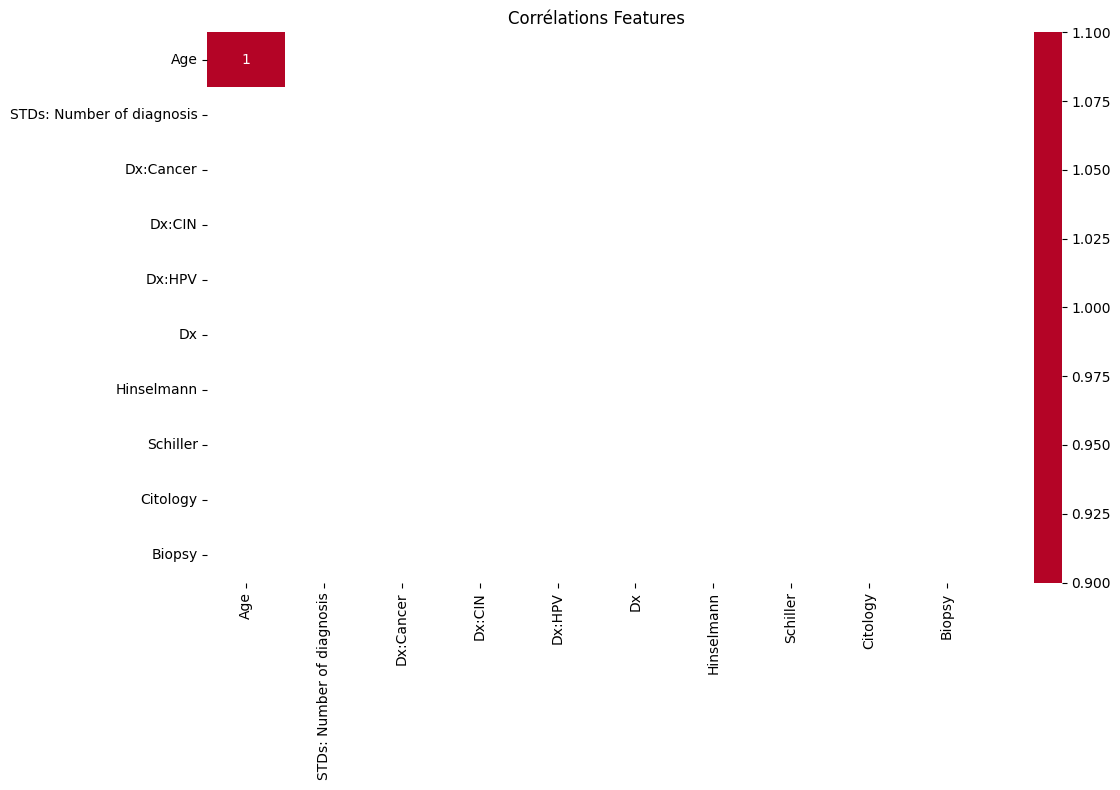

✅ EDA TERMINÉ - processed_data.csv sauvé


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# CHARGER DATASET
df = pd.read_csv('../data.csv')
print("✅ Dataset chargé:", df.shape)
print(df.head())
print("\n🎯 Distribution Biopsy (85/15 imbalance):")
print(df['Biopsy'].value_counts(normalize=True))

# MISSING VALUES
print("\n🔍 Missing values:")
print(df.isnull().sum())
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
cat_cols = df.select_dtypes(exclude=np.number).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode().iloc[0] if not df[col].mode().empty else 0)

# OUTLIERS
print("\n🛡️ Outliers clippés:")
for col in num_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower=lower, upper=upper)
    print(f"  {col}: {outliers} outliers")

# CORRELATIONS
plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Corrélations Features")
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300)
plt.show()

# SAUVEGARDER
df.to_csv('../data/processed_data.csv', index=False)
print("✅ EDA TERMINÉ - processed_data.csv sauvé")
